## Generate Training Spectra


In [2]:
import gc
import os
import re
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import multirex as mrex
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def remove_warnings() -> None:
    """Suppress deprecation warnings produced by external dependencies."""
    warnings.filterwarnings("ignore", category=DeprecationWarning)


waves = np.loadtxt("waves.txt")
n_points = len(waves)



# Wavenumber grid used by downstream spectral operations.
wn_grid = np.sort(10000 / waves)



def attach_spectrum_blocks(df, n_data_columns):
    """Attach local `.data` and `.params` views used by this notebook."""
    object.__setattr__(df, "data", df.iloc[:, -n_data_columns:])
    object.__setattr__(df, "params", df.iloc[:, :-n_data_columns])
    return df


Loading MultiREx version 0.3.1


## Load Spectral Data


In [3]:
def apply_contaminations_from_files(contamination_files, df, n_points):
    """
    Apply multiple contaminations to a DataFrame using a list of contamination files.

    The output includes:
    - A non-contaminated case (f_spot = 0.0, f_fac = 0.0)
    - One contaminated copy per file, where the last `n_points` columns are scaled
      by the contamination vector read from that file.

    The file name is expected to encode parameters using:
        fspot<value>_ffac<value>.txt

    Parameters
    ----------
    contamination_files : list of str
        Paths to `.txt` files containing contamination vectors.
    df : pandas.DataFrame
        Original DataFrame to which contaminations will be applied.
    n_points : int
        Number of trailing columns to scale by the contamination vector.

    Returns
    -------
    pandas.DataFrame
        Concatenated DataFrame including the non-contaminated case and all
        contaminations. Three columns are prepended: `contam_source`, `f_spot`,
        and `f_fac`.

    Notes
    -----
    This function attaches two convenience attributes to the returned DataFrame:
    - `df_final.data`: last `n_points` columns
    - `df_final.params`: all other columns
    """
    df_list = []

    # --- Non-contaminated case ---
    df_no_contam = df.copy()
    df_no_contam["contam_source"] = "clean"
    df_no_contam["f_spot"] = 0.0
    df_no_contam["f_fac"] = 0.0

    cols = ["contam_source", "f_spot", "f_fac"] + [
        col
        for col in df_no_contam.columns
        if col not in ["contam_source", "f_spot", "f_fac"]
    ]
    df_no_contam = df_no_contam[cols]
    df_list.append(df_no_contam)

    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file '{file_path}' does not exist.")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(
                f"The file name '{filename}' does not match the expected pattern "
                f"'fspot<value>_ffac<value>.txt'."
            )

        contam_source = "sphinx" if filename.startswith("sphinx_") else "original"
        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)

            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()

            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' "
                    f"({len(contam_values)}) does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file '{file_path}': {e}") from e

        contam_values = contam_values[::-1]

        df_contam = df.copy()
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(
            contam_values, axis=1
        )

        df_contam["contam_source"] = contam_source
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        cols = ["contam_source", "f_spot", "f_fac"] + [
            col
            for col in df_contam.columns
            if col not in ["contam_source", "f_spot", "f_fac"]
        ]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    df_final = pd.concat(df_list, ignore_index=True)

    return attach_spectrum_blocks(df_final, n_points)


In [4]:
contamination_dir = "stellar_contamination"
contamination_files = [
    os.path.join(contamination_dir, filename).replace("\\", "/")
    for filename in sorted(
        os.listdir(contamination_dir), key=lambda name: (name.startswith("sphinx_"), name)
    )
    if filename.endswith(".txt") and "TRAPPIST-1_contam_fspot" in filename
]


def filter_rows(df):
    """
    Filter rows where at least one of the target atmospheric columns is >= -8.

    If none of the target columns exist, the DataFrame is returned unchanged.

    Notes
    -----
    This function preserves the original behavior of sequential filtering when
    multiple columns are present (each filter is applied on the result of the
    previous one).
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]

    return attach_spectrum_blocks(df, n_points)


remove_warnings()

datasets = [
    ("airless_data", "spec_data/airless_data.csv", False),
    ("CO2_data", "spec_data/CO2_data.csv", False),
    ("CH4_data", "spec_data/CH4_data.csv", True),
    ("O3_data", "spec_data/O3_data.csv", True),
    ("H2O_data", "spec_data/H2O_data.csv", True),
    ("CH4_O3_data", "spec_data/CH4_O3_data.csv", True),
    ("CH4_H2O_data", "spec_data/CH4_H2O_data.csv", True),
    ("O3_H2O_data", "spec_data/O3_H2O_data.csv", True),
    ("CH4_O3_H2O_data", "spec_data/CH4_O3_H2O_data.csv", True),
]

for name, path, needs_filter in datasets:
    try:
        df = pd.read_csv(path)

        if needs_filter:
            df = filter_rows(df)

        df = apply_contaminations_from_files(contamination_files, df, n_points)
        globals()[name] = df  # Keep the original variable names in the notebook.
    except Exception as e:
        print(f"Error processing {name}: {e}")

C:\Users\User\AppData\Local\Temp\ipykernel_73084\1397645432.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["contam_source"] = contam_source
C:\Users\User\AppData\Local\Temp\ipykernel_73084\1397645432.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_73084\1397645432.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

In [5]:
REF_FLAT = None
LOG_RATIO_EPS = 1e-12


def infer_ref_flat_from_airless(airless_df, n_points, atol=1e-12, rtol=1e-8):
    """Infer a scalar flat reference depth from the clean airless spectrum."""
    mask = np.ones(len(airless_df), dtype=bool)

    if "f_spot" in airless_df.columns:
        mask &= np.isclose(airless_df["f_spot"].to_numpy(dtype=float), 0.0)
    if "f_fac" in airless_df.columns:
        mask &= np.isclose(airless_df["f_fac"].to_numpy(dtype=float), 0.0)
    if "contam_source" in airless_df.columns:
        mask &= airless_df["contam_source"].astype(str).to_numpy() == "clean"

    airless_subset = airless_df.loc[mask]
    if airless_subset.empty:
        raise ValueError("Could not find a contamination-free airless spectrum.")

    airless_values = airless_subset.iloc[0, -n_points:].to_numpy(dtype=np.float32)
    ref_flat = float(np.median(airless_values))

    if not np.allclose(airless_values, ref_flat, atol=atol, rtol=rtol):
        raise ValueError("Airless spectrum is not flat enough to define a scalar ref_flat.")
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"Invalid ref_flat inferred from airless spectrum: {ref_flat}")

    return ref_flat


def _wrap_like(original, values):
    if isinstance(original, pd.DataFrame):
        return pd.DataFrame(values, index=original.index, columns=original.columns)
    if isinstance(original, pd.Series):
        return pd.Series(values, index=original.index, name=original.name)
    return values


def to_log_ratio(values, ref_flat, eps=LOG_RATIO_EPS):
    """Transform physical transit depths to log(depth / ref_flat)."""
    ref_flat = float(ref_flat)
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"ref_flat must be a positive finite float, got {ref_flat}")

    arr = np.asarray(values, dtype=np.float32)
    arr = np.clip(arr, eps, None)
    transformed = np.log(arr / ref_flat).astype(np.float32)
    return _wrap_like(values, transformed)


def from_log_ratio(values_log, ref_flat):
    """Map log(depth / ref_flat) back to physical transit depths."""
    ref_flat = float(ref_flat)
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"ref_flat must be a positive finite float, got {ref_flat}")

    arr = np.asarray(values_log, dtype=np.float32)
    restored = (np.exp(arr) * ref_flat).astype(np.float32)
    return _wrap_like(values_log, restored)


## Build Clean Reference Data


In [6]:
def mult_df(df, n_points, n_mult):
    """
    Duplicate a DataFrame `n_mult + 1` times and prepend contamination parameters.

    Each duplicate is a copy of `df` with two added columns:
    - 'f_spot' = 0.0
    - 'f_fac' = 0.0

    The returned DataFrame also exposes two convenience attributes:
    - `.data`: last `n_points` columns
    - `.params`: all remaining columns

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame to duplicate.
    n_points : int
        Number of trailing columns treated as the "data" block.
    n_mult : int
        Number of extra duplicates; total copies will be `n_mult + 1`.

    Returns
    -------
    pandas.DataFrame
        Concatenated DataFrame with `n_mult + 1` copies and 'f_spot'/'f_fac'
        columns placed first.
    """
    df_list = []

    for _ in range(n_mult + 1):
        df_no_contam = df.copy()
        df_no_contam["contam_source"] = "clean"
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0

        cols = ["contam_source", "f_spot", "f_fac"] + [
            col
            for col in df_no_contam.columns
            if col not in ["contam_source", "f_spot", "f_fac"]
        ]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    df_final = pd.concat(df_list, ignore_index=True)
    return attach_spectrum_blocks(df_final, n_points)


In [7]:
datasets_clean = [
    ("airless_data_clean", "spec_data/airless_data.csv", False),
    ("CO2_data_clean", "spec_data/CO2_data.csv", False),
    ("CH4_data_clean", "spec_data/CH4_data.csv", True),
    ("O3_data_clean", "spec_data/O3_data.csv", True),
    ("H2O_data_clean", "spec_data/H2O_data.csv", True),
    ("CH4_O3_data_clean", "spec_data/CH4_O3_data.csv", True),
    ("CH4_H2O_data_clean", "spec_data/CH4_H2O_data.csv", True),
    ("O3_H2O_data_clean", "spec_data/O3_H2O_data.csv", True),
    ("CH4_O3_H2O_data_clean", "spec_data/CH4_O3_H2O_data.csv", True),
]

for name, path, needs_filter in datasets_clean:
    try:
        df = pd.read_csv(path)

        if needs_filter:
            df = filter_rows(df)

        df = mult_df(df, n_points, len(contamination_files))
        globals()[name] = df
    except Exception as e:
        print(f"Error processing {name}: {e}")


# Add Instrumental Noise

The following cells build paired noisy and clean datasets for each S/N level.


In [8]:
def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """Repeat spectra and add Gaussian noise with scalar or per-row noise levels."""
    if n_repeat <= 0:
        raise ValueError("n_repeat must be positive.")

    if seed is not None:
        np.random.seed(seed)

    df_params = df.params
    df_spectra = df.data

    spectra_repeated = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns,
    )

    if np.isscalar(noise_std):
        if noise_std < 0:
            raise ValueError("noise_std must be non-negative.")
        noise_repeated = np.full(spectra_repeated.shape, noise_std)
        noise_column = noise_std
    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if len(noise_array) != len(df_spectra):
            raise ValueError("noise_std must match the number of input spectra.")
        if np.any(noise_array < 0):
            raise ValueError("noise_std values must be non-negative.")

        noise_repeated = np.repeat(noise_array[:, None], n_repeat, axis=0)
        noise_repeated = np.tile(noise_repeated, (1, spectra_repeated.shape[1]))
        noise_column = np.repeat(noise_array, n_repeat)

    gaussian_noise = np.random.normal(
        loc=0.0,
        scale=noise_repeated,
        size=spectra_repeated.shape,
    )
    spectra_repeated += gaussian_noise

    params_repeated = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns,
    )
    params_repeated.insert(0, "noise_std", noise_column)
    params_repeated.insert(1, "n_repeat", n_repeat)

    df_final = pd.concat(
        [params_repeated.reset_index(drop=True), spectra_repeated.reset_index(drop=True)],
        axis=1,
    )

    return attach_spectrum_blocks(df_final, spectra_repeated.shape[1])


## S/N = 1


In [ ]:
DATASET_ORDER = [
    "CO2",
    "CH4",
    "O3",
    "H2O",
    "CH4_O3",
    "CH4_H2O",
    "O3_H2O",
    "CH4_O3_H2O",
    "airless",
]

SPECTRAL_DATASETS = {
    "CO2": CO2_data,
    "CH4": CH4_data,
    "O3": O3_data,
    "H2O": H2O_data,
    "CH4_O3": CH4_O3_data,
    "CH4_H2O": CH4_H2O_data,
    "O3_H2O": O3_H2O_data,
    "CH4_O3_H2O": CH4_O3_H2O_data,
    "airless": airless_data,
}

CLEAN_DATASETS = {
    "CO2": CO2_data_clean,
    "CH4": CH4_data_clean,
    "O3": O3_data_clean,
    "H2O": H2O_data_clean,
    "CH4_O3": CH4_O3_data_clean,
    "CH4_H2O": CH4_H2O_data_clean,
    "O3_H2O": O3_H2O_data_clean,
    "CH4_O3_H2O": CH4_O3_H2O_data_clean,
    "airless": airless_data_clean,
}

REPEAT_COUNTS = {
    1: {
        "CO2": 3_000,
        "CH4": 300,
        "O3": 300,
        "H2O": 300,
        "CH4_O3": 30,
        "CH4_H2O": 30,
        "O3_H2O": 30,
        "CH4_O3_H2O": 6,
        "airless": 3_000,
    },
    3: {
        "CO2": 3_000,
        "CH4": 300,
        "O3": 300,
        "H2O": 300,
        "CH4_O3": 30,
        "CH4_H2O": 30,
        "O3_H2O": 30,
        "CH4_O3_H2O": 6,
        "airless": 3_000,
    },
    6: {
        "CO2": 2_500,
        "CH4": 250,
        "O3": 250,
        "H2O": 250,
        "CH4_O3": 30,
        "CH4_H2O": 30,
        "O3_H2O": 30,
        "CH4_O3_H2O": 6,
        "airless": 2_500,
    },
    10: {
        "CO2": 2_000,
        "CH4": 200,
        "O3": 200,
        "H2O": 200,
        "CH4_O3": 20,
        "CH4_H2O": 20,
        "O3_H2O": 20,
        "CH4_O3_H2O": 5,
        "airless": 2_000,
    },
    "noiseless": {
        "CO2": 5_000,
        "CH4": 500,
        "O3": 500,
        "H2O": 500,
        "CH4_O3": 50,
        "CH4_H2O": 50,
        "O3_H2O": 50,
        "CH4_O3_H2O": 7,
        "airless": 4_000,
    },
}


def build_snr_pair(snr, repeat_counts):
    """Build matched noisy and clean DataFrames for one S/N setting."""
    noise_std = 0 if snr is None else mrex.generate_df_SNR_noise(
        df=CO2_data,
        n_repeat=1,
        SNR=snr,
    )["noise"][1]

    noisy_parts = [
        generate_df_with_noise_std(
            df=SPECTRAL_DATASETS[key],
            n_repeat=repeat_counts[key],
            noise_std=noise_std,
        )
        for key in DATASET_ORDER
    ]
    noisy_df = pd.concat(noisy_parts, ignore_index=True)
    noisy_df = attach_spectrum_blocks(noisy_df, n_points)

    clean_parts = [
        generate_df_with_noise_std(
            df=CLEAN_DATASETS[key],
            n_repeat=repeat_counts[key],
            noise_std=0,
        )
        for key in DATASET_ORDER
    ]
    clean_df = pd.concat(clean_parts, ignore_index=True)
    clean_df = attach_spectrum_blocks(clean_df, n_points)

    del noisy_parts, clean_parts
    gc.collect()

    print("Clean and noisy dataframes have the same shape:", noisy_df.shape == clean_df.shape)
    return noisy_df, clean_df


SNR1_df, SNR1_no_df = build_snr_pair(1, REPEAT_COUNTS[1])


Clean and noisy dataframes have the same shape: True


## S/N = 3


In [ ]:
SNR3_df, SNR3_no_df = build_snr_pair(3, REPEAT_COUNTS[3])


Clean and noisy dataframes have the same shape: True


## S/N = 6


In [ ]:
SNR6_df, SNR6_no_df = build_snr_pair(6, REPEAT_COUNTS[6])


Clean and noisy dataframes have the same shape: True


## S/N = 10


In [ ]:
SNR10_df, SNR10_no_df = build_snr_pair(10, REPEAT_COUNTS[10])


Clean and noisy dataframes have the same shape: True


## Noiseless Reference


In [12]:
SNRNan_df, SNRNan_no_df = build_snr_pair(None, REPEAT_COUNTS["noiseless"])


Clean and noisy dataframes have the same shape: True


## Assemble Training Arrays


In [13]:
# Extract and transform the spectral block to log(depth / ref_flat) for each dataset to save memory.
ref_flat = float(REF_FLAT) if REF_FLAT is not None else infer_ref_flat_from_airless(
    airless_data, n_points
)
print(f"Using ref_flat = {ref_flat:.12e}")

# Process noisy datasets individually
noisy_list = []
for df_name in ["SNR1_df", "SNR3_df", "SNR6_df", "SNR10_df", "SNRNan_df"]:
    df = globals()[df_name]
    arr = df.iloc[:, -n_points:].values.astype(np.float32)
    arr_log = to_log_ratio(arr, ref_flat)
    noisy_list.append(arr_log)
    del globals()[df_name]
    gc.collect()

X_noisy = np.concatenate(noisy_list, axis=0)
del noisy_list
gc.collect()

# Process clean counterparts individually
clean_list = []
for df_name in ["SNR1_no_df", "SNR3_no_df", "SNR6_no_df", "SNR10_no_df", "SNRNan_no_df"]:
    df = globals()[df_name]
    arr = df.iloc[:, -n_points:].values.astype(np.float32)
    arr_log = to_log_ratio(arr, ref_flat)
    clean_list.append(arr_log)
    del globals()[df_name]
    gc.collect()

X_no_noisy = np.concatenate(clean_list, axis=0)
del clean_list
gc.collect()

assert X_noisy.shape[0] == X_no_noisy.shape[0], (
    "The number of samples does not match between X_noisy and X_clean."
)


Using ref_flat = 5.006817635149e-03


### Final Training Data


In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


<frozen importlib._bootstrap>:488: DeprecationWarning: Type google.protobuf.pyext._message.ScalarMapContainer uses PyType_Spec with a metaclass that has custom tp_new. This is deprecated and will no longer be allowed in Python 3.14.
<frozen importlib._bootstrap>:488: DeprecationWarning: Type google.protobuf.pyext._message.MessageMapContainer uses PyType_Spec with a metaclass that has custom tp_new. This is deprecated and will no longer be allowed in Python 3.14.


In [15]:
test_size = 0.2

X_train_noisy, X_test_noisy, X_train_clean, X_test_clean = train_test_split(
    X_noisy,
    X_no_noisy,
    test_size=test_size,
)

del X_noisy, X_no_noisy
gc.collect()


0

In [16]:
len(X_train_noisy) +  len(X_test_noisy)

5905960

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select 10 random indices from the training set
num_samples = 10
random_indices = np.random.choice(len(X_train_noisy), num_samples, replace=False)

# 2. Configure the visualization grid (5 rows x 2 columns)
fig, axes = plt.subplots(5, 2, figsize=(16, 22), sharex=True)
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    ax = axes[i]
    
    # Plot the clean (blue) and noisy (orange) spectra in log-ratio space
    # Use the wavelength array 'waves' on the x-axis
    ax.plot(waves, X_train_clean[idx][::-1], label="Clean target (log ratio)", color="#1f77b4", alpha=0.8, lw=1.5)
    ax.plot(waves, X_train_noisy[idx][::-1], label="Noisy input (log ratio)", color="#ff7f0e", alpha=0.6, lw=1.0)
    
    ax.set_title(f"Training sample - index {idx}", fontsize=11, fontweight='bold')
    ax.set_ylabel("log(depth / ref_flat)", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Show the x-axis label only on the final row
    if i >= 8:
        ax.set_xlabel(r"Wavelength ($\mu$m)", fontsize=10)
    
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


### Autoencoder


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

input_dim = X_train_noisy.shape[1]
l2_lambda = 1e-7

assert input_dim in {n_points, 2 * n_points}, (
    f"Unexpected input_dim={input_dim}. Expected n_points={n_points} "
    f"or 2*n_points={2 * n_points}."
)

input_spectrum = keras.Input(shape=(input_dim,))

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(input_spectrum)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

decoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

output = layers.Dense(n_points, activation="linear")(decoded)

autoencoder = keras.Model(inputs=input_spectrum, outputs=output)

optimizer = Adam(learning_rate=1e-5)
autoencoder.compile(optimizer=optimizer, loss="mae")

autoencoder.summary()


Epoch 1/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 706s 10ms/step - loss: 0.0060 - val_loss: 0.0041
Epoch 2/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 699s 9ms/step - loss: 0.0045 - val_loss: 0.0040
Epoch 3/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 699s 9ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 4/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 706s 10ms/step - loss: 0.0043 - val_loss: 0.0039
Epoch 5/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 700s 9ms/step - loss: 0.0040 - val_loss: 0.0027
Epoch 6/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 698s 9ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 7/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 698s 9ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 8/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 699s 9ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 9/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 696s 9ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 10/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 695s 9ms/step - loss: 0.0028 - val_loss: 0.0020
Epoch 11/100
73825/73825 ━━━━━━━━━━━━━━━━━━━━ 698s 9ms/step - loss:

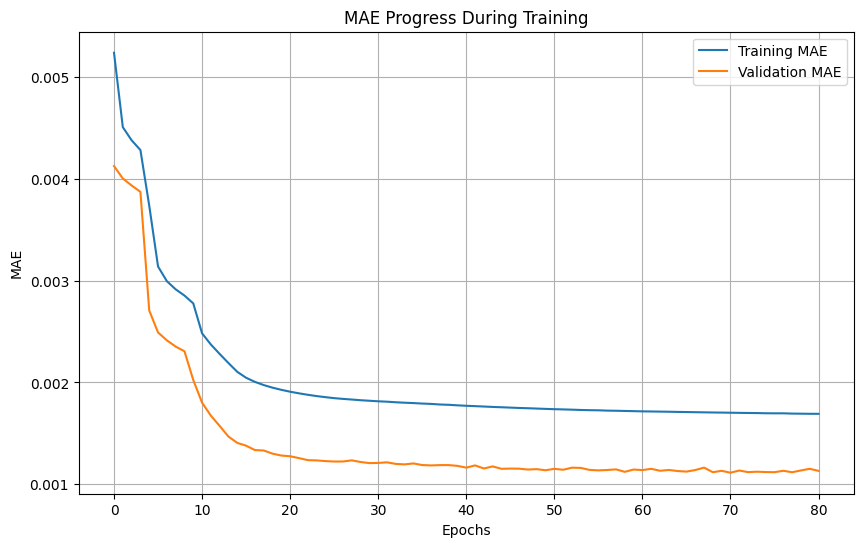

36913/36913 ━━━━━━━━━━━━━━━━━━━━ 215s 6ms/step


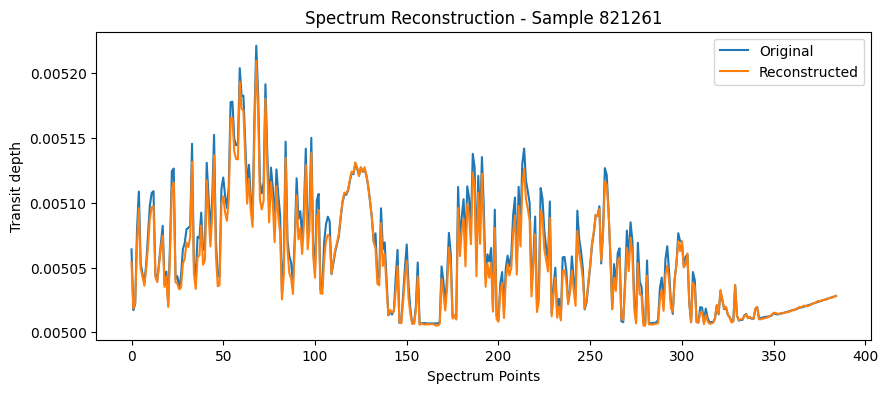

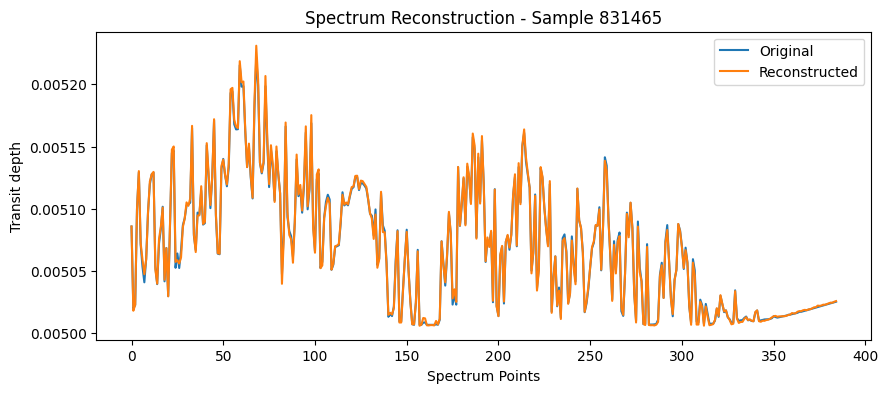

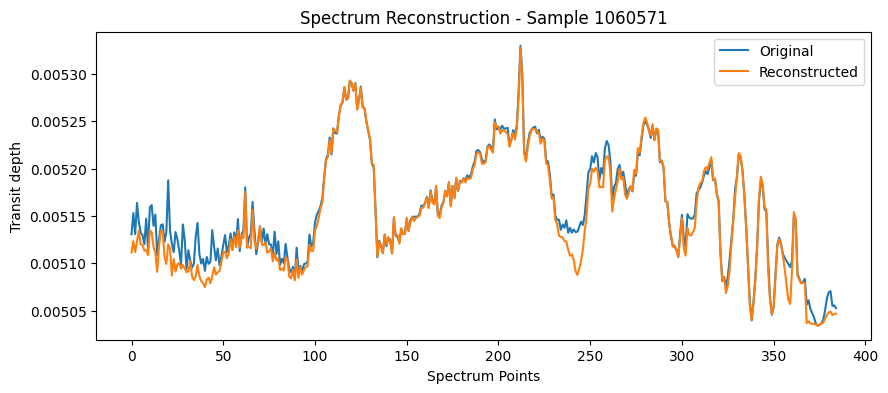

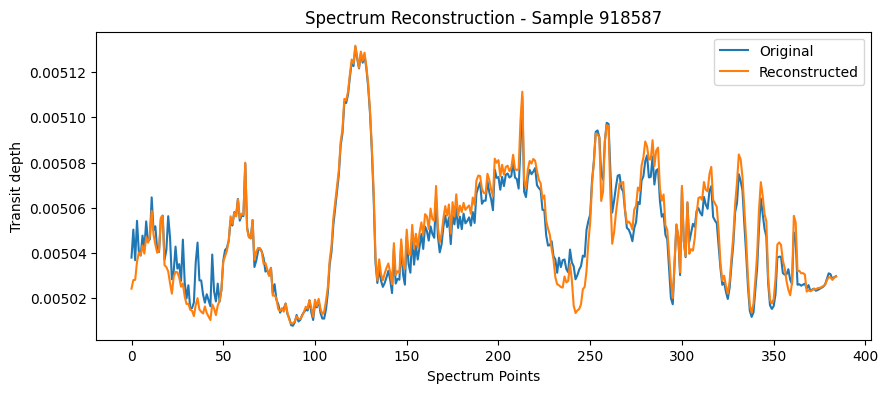

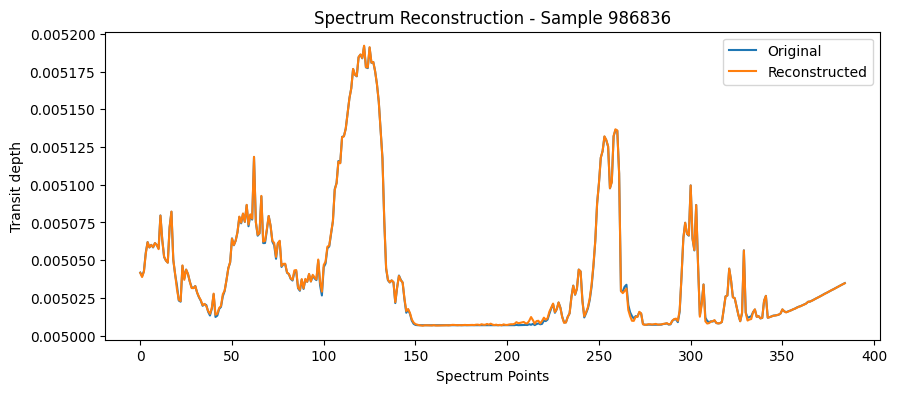

In [21]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_noisy,
    X_train_clean,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test_noisy, X_test_clean),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
)

# Save the trained model
autoencoder.save("Models/G-DAE.keras")

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training MAE")
plt.plot(history.history["val_loss"], label="Validation MAE")
plt.title("MAE Progress During Training")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

# Predict reconstructed spectra on test data
decoded_spectra_log = autoencoder.predict(X_test_noisy)
decoded_spectra = from_log_ratio(decoded_spectra_log, ref_flat)
X_test_clean_physical = from_log_ratio(X_test_clean, ref_flat)

# Visualize a few reconstructions in physical transit depth
num_samples = 5  # Number of samples to visualize
indices = np.random.choice(len(X_test_noisy), num_samples, replace=False)

for idx in indices:
    plt.figure(figsize=(10, 4))
    plt.plot(X_test_clean_physical[idx].flatten(), label="Original")
    plt.plot(decoded_spectra[idx].flatten(), label="Reconstructed")
    plt.xlabel("Spectrum Points")
    plt.ylabel("Transit depth")
    plt.title(f"Spectrum Reconstruction - Sample {idx}")
    plt.legend()
    plt.show()


# Evaluation


In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras

# Load the trained autoencoder model and reconstruct the test spectra
autoencoder = keras.models.load_model("Models/G-DAE.keras")

X_reconstructed = autoencoder.predict(X_test_noisy)

# --- PHYSICAL SPACE EVALUATION ---
# Map log-ratio representation back to physical transit depths
X_test_clean_physical = from_log_ratio(X_test_clean, ref_flat)
X_reconstructed_physical = from_log_ratio(X_reconstructed, ref_flat)

# Compute physical space metrics
mae_phys = mean_absolute_error(X_test_clean_physical, X_reconstructed_physical)
mse_phys = mean_squared_error(X_test_clean_physical, X_reconstructed_physical)
r2_phys = r2_score(X_test_clean_physical, X_reconstructed_physical)

# Extract the clean CO2 physical spectrum used in the notebook examples (cell 35)
co2_clean_physical = CO2_data[
    (CO2_data["f_spot"] == 0.0) & (CO2_data["f_fac"] == 0.0)
].iloc[1, -n_points:].to_numpy(dtype=np.float32)

co2_physical_range = np.max(co2_clean_physical) - np.min(co2_clean_physical)

# Compute percentages in physical space
mae_phys_pct = (mae_phys / co2_physical_range) * 100
mse_phys_pct_range = (mse_phys / co2_physical_range) * 100
mse_phys_pct_range_sq = (mse_phys / (co2_physical_range ** 2)) * 100
rmse_phys_pct = (np.sqrt(mse_phys) / co2_physical_range) * 100

# --- LOG-RATIO SPACE EVALUATION (For reference, matching loss function space) ---
mae_log = mean_absolute_error(X_test_clean, X_reconstructed)
mse_log = mean_squared_error(X_test_clean, X_reconstructed)
r2_log = r2_score(X_test_clean, X_reconstructed)

co2_clean_log = to_log_ratio(co2_clean_physical, ref_flat)
co2_log_range = np.max(co2_clean_log) - np.min(co2_clean_log)

mae_log_pct = (mae_log / co2_log_range) * 100
mse_log_pct_range_sq = (mse_log / (co2_log_range ** 2)) * 100
rmse_log_pct = (np.sqrt(mse_log) / co2_log_range) * 100

print("=================================================================")
print("                    PHYSICAL SPACE METRICS")
print("               (Evaluated on physical transit depths)")
print("=================================================================")
print(f"Mean Absolute Error (MAE): {mae_phys:.6e}")
print(f"Mean Squared Error (MSE): {mse_phys:.6e}")
print(f"Coefficient of Determination (R²): {r2_phys:.6f}")
print()
print(f"Reference CO2 Physical Range: {co2_physical_range:.6e}")
print(f"MAE in % of CO2 range: {mae_phys_pct:.6f}%")
print(f"MSE in % of CO2 range (normalized by range): {mse_phys_pct_range:.6f}%")
print(f"MSE in % of CO2 range squared (normalized by range^2): {mse_phys_pct_range_sq:.6f}%")
print(f"RMSE in % of CO2 range: {rmse_phys_pct:.6f}%")
print()
print("=================================================================")
print("                   LOG-RATIO SPACE METRICS")
print("               (Evaluated on training representation)")
print("=================================================================")
print(f"Mean Absolute Error (MAE): {mae_log:.6f}")
print(f"Mean Squared Error (MSE): {mse_log:.6f}")
print(f"Coefficient of Determination (R²): {r2_log:.6f}")
print()
print(f"Reference CO2 Log Range: {co2_log_range:.6f}")
print(f"MAE in % of CO2 range: {mae_log_pct:.6f}%")
print(f"MSE in % of CO2 range squared (normalized by range^2): {mse_log_pct_range_sq:.6f}%")
print(f"RMSE in % of CO2 range: {rmse_log_pct:.6f}%")

36913/36913 ━━━━━━━━━━━━━━━━━━━━ 199s 5ms/step
                    PHYSICAL SPACE METRICS
               (Evaluated on physical transit depths)
Mean Absolute Error (MAE): 5.051385e-06
Mean Squared Error (MSE): 1.531340e-10
Coefficient of Determination (R²): 0.958270

Reference CO2 Physical Range: 1.849257e-04
MAE in % of CO2 range: 2.731575%
MSE in % of CO2 range (normalized by range): 0.000083%
MSE in % of CO2 range squared (normalized by range^2): 0.447793%
RMSE in % of CO2 range: 6.691730%

                   LOG-RATIO SPACE METRICS
               (Evaluated on training representation)
Mean Absolute Error (MAE): 0.000992
Mean Squared Error (MSE): 0.000006
Coefficient of Determination (R²): 0.947724

Reference CO2 Log Range: 0.036269
MAE in % of CO2 range: 2.735253%
MSE in % of CO2 range squared (normalized by range^2): 0.446740%
RMSE in % of CO2 range: 6.683861%


## Reconstruction Plot


In [10]:
noise =  mrex.generate_df_SNR_noise(
    df=CO2_data,
    n_repeat=1,
    SNR=3     
)["noise"][1]


SNR3_CO2_data = generate_df_with_noise_std(
    df=CO2_data,
    n_repeat=10_000,
    noise_std = noise     
)

SNR3_CH4_data = generate_df_with_noise_std(
    df=CH4_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_O3_data = generate_df_with_noise_std(
    df=O3_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_H2O_data = generate_df_with_noise_std(
    df=H2O_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_CH4_O3_data = generate_df_with_noise_std(
    df=CH4_O3_data,
    n_repeat=350, # 350 for graph
    noise_std = noise
)

SNR3_CH4_H2O_data = generate_df_with_noise_std(
    df=CH4_H2O_data,
    n_repeat=30,
    noise_std = noise
)

SNR3_O3_H2O_data = generate_df_with_noise_std(
    df=O3_H2O_data,
    n_repeat=30,
    noise_std = noise
)

SNR3_CH4_O3_H2O_data = generate_df_with_noise_std(
    df=CH4_O3_H2O_data,
    n_repeat=5,
    noise_std = noise
)
    
SNR3_airless_data = generate_df_with_noise_std(
    df=airless_data,
    n_repeat=10_000,
    noise_std = noise   
)

SNR3_df = pd.concat(
    [
        SNR3_CO2_data,
        SNR3_CH4_data,
        SNR3_O3_data,
        SNR3_H2O_data,
        SNR3_CH4_O3_data,
        SNR3_CH4_H2O_data,
        SNR3_O3_H2O_data,
        SNR3_CH4_O3_H2O_data,
        SNR3_airless_data
    ],
    ignore_index=True
) 


del (
        SNR3_CO2_data,
        SNR3_CH4_data,
        SNR3_O3_data,
        SNR3_H2O_data,
        SNR3_CH4_O3_data,
        SNR3_CH4_H2O_data,
        SNR3_O3_H2O_data,
        SNR3_CH4_O3_H2O_data,
        SNR3_airless_data
        
)

gc.collect()


714

In [11]:
# Extract and transform the spectral block to log(depth / ref_flat) for each dataset to save memory.
ref_flat = float(REF_FLAT) if REF_FLAT is not None else infer_ref_flat_from_airless(
    airless_data, n_points
)
print(f"Using ref_flat = {ref_flat:.12e}")

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras

# Load the trained autoencoder model and reconstruct the test spectra
autoencoder = keras.models.load_model("Models/G-DAE.keras")


Using ref_flat = 5.006817635149e-03


In [15]:
# Display the first few rows (for quick sanity check).
SNR3_df.head()

# Filter the DataFrame for a specific stellar contamination configuration.
target_contam_source = "original"
auto_SNR3_raw_df = SNR3_df[
    (SNR3_df["contam_source"] == target_contam_source)
    & (SNR3_df["f_spot"] == 0.08)
    & (SNR3_df["f_fac"] == 0.54)
].copy()

# Transform to the model space, predict, and map the reconstruction back.
auto_SNR3_log_df = auto_SNR3_raw_df.copy()
auto_SNR3_log_df.iloc[:, -n_points:] = to_log_ratio(
    auto_SNR3_log_df.iloc[:, -n_points:], ref_flat
)

X_log = auto_SNR3_log_df.iloc[:, -n_points:].values.astype(np.float32)
X_recon_log = autoencoder.predict(X_log)

auto_reconstructed_SNR3_df = auto_SNR3_raw_df.copy()
auto_reconstructed_SNR3_df.iloc[:, -n_points:] = from_log_ratio(X_recon_log, ref_flat)

# Non-atmospheric CO2 example (atm CO2 == 0).
airless_SNR3 = auto_SNR3_raw_df[auto_SNR3_raw_df["atm CO2"] == 0].iloc[
    1, -n_points:
].to_numpy(dtype=np.float32)
airless_reconstructed_SNR3 = auto_reconstructed_SNR3_df[
    auto_reconstructed_SNR3_df["atm CO2"] == 0
].iloc[1, -n_points:].to_numpy(dtype=np.float32)

# Clean reference for the airless case.
airless_clean_df = airless_data[
    (airless_data["f_spot"] == 0.0) & (airless_data["f_fac"] == 0.0)
].copy()
airless_clean = airless_clean_df.iloc[0, -n_points:].to_numpy(dtype=np.float32)

# CO2 analysis: select a row index `i` (fixed at 13995) under CH4=O3=H2O=0.
co2_mask = (
    (auto_SNR3_raw_df["atm CH4"] == 0)
    & (auto_SNR3_raw_df["atm O3"] == 0)
    & (auto_SNR3_raw_df["atm H2O"] == 0)
)
i_co2 = 13995
print(f"CO2 = {i_co2}")

CO2_SNR3_df = auto_SNR3_raw_df[co2_mask].iloc[i_co2, -n_points:].to_numpy(dtype=np.float32)

CO2_reconstructed_SNR3 = auto_reconstructed_SNR3_df[co2_mask].iloc[i_co2, -n_points:].to_numpy(dtype=np.float32)

CO2_clean_df = CO2_data[
    (CO2_data["f_spot"] == 0.0) & (CO2_data["f_fac"] == 0.0)
].copy()
CO2_clean = CO2_clean_df.iloc[1, -n_points:].to_numpy(dtype=np.float32)

# Biosignature analysis: select a row index `i` randomly for specific CH4/O3/H2O values.
bio_mask = (
    (auto_SNR3_raw_df["atm CH4"] == -5)
    & (auto_SNR3_raw_df["atm O3"] == -7)
    & (auto_SNR3_raw_df["atm H2O"] == 0)
)
i_bio = 717
print(f"bio = {i_bio}")

bio_SNR3_df = auto_SNR3_raw_df[bio_mask].iloc[i_bio, -n_points:].to_numpy(dtype=np.float32)

bio_reconstructed_SNR3 = auto_reconstructed_SNR3_df[bio_mask].iloc[i_bio, -n_points:].to_numpy(dtype=np.float32)

bio_clean_df = CH4_O3_data[
    (CH4_O3_data["f_spot"] == 0.0)
    & (CH4_O3_data["f_fac"] == 0.0)
    & (CH4_O3_data["atm CH4"] == -5)
    & (CH4_O3_data["atm O3"] == -7)
    & (CH4_O3_data["atm H2O"] == 0)
].copy()
bio_clean = bio_clean_df.iloc[2, -n_points:].to_numpy(dtype=np.float32)

X_clean = [airless_clean, CO2_clean, bio_clean]
X_noisy = [airless_SNR3, CO2_SNR3_df, bio_SNR3_df]
X_reconstructed = [
    airless_reconstructed_SNR3,
    CO2_reconstructed_SNR3,
    bio_reconstructed_SNR3,
]


4513/4513 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
CO2 = 13995
bio = 717


In [16]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["STIXGeneral", "DejaVu Serif", "Times New Roman", "CMU Serif", "Liberation Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["axes.titlesize"] = 20
mpl.rcParams["axes.titleweight"] = "normal"
mpl.rcParams["axes.titlepad"] = 10
mpl.rcParams["figure.titlesize"] = 20
mpl.rcParams["figure.titleweight"] = "normal"


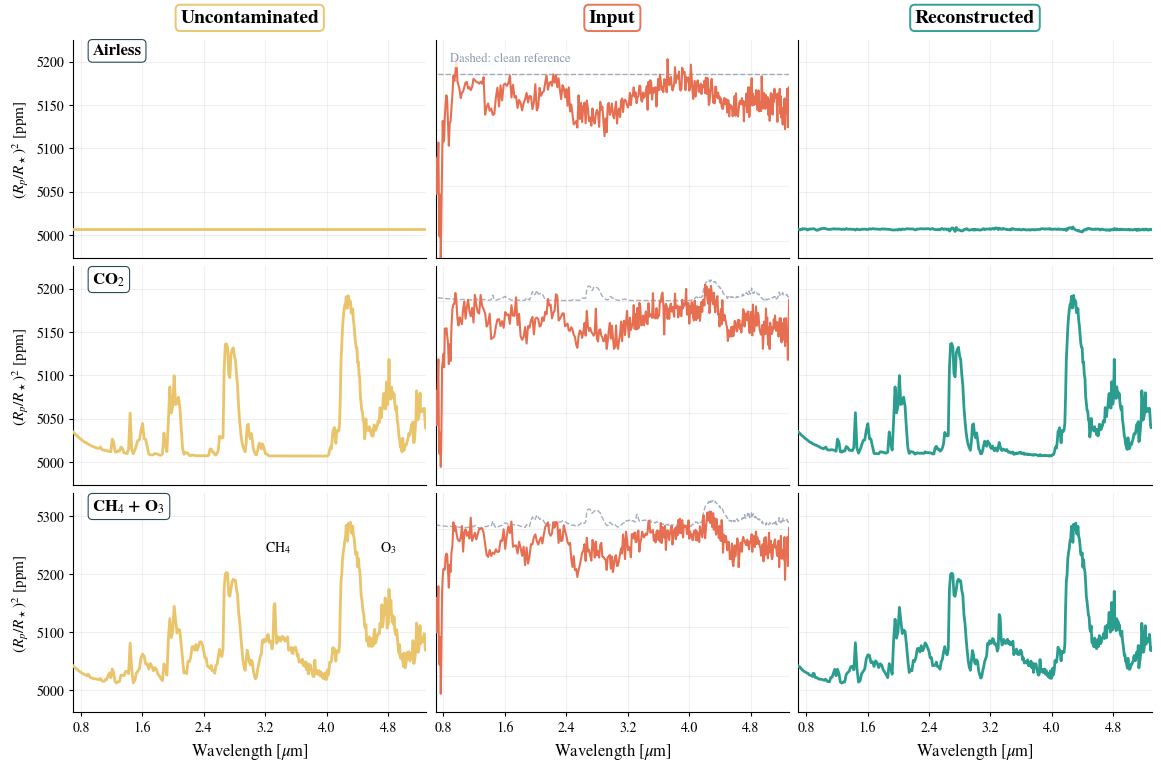

In [17]:
PALETTE = {
    "ink": "#264653",
    "teal": "#2A9D8F",  # Reconstructed
    "sand": "#E9C46A",  # Clean
    "apricot": "#F4A261",
    "tomato": "#E76F51",  # Input
    "ghost": "#8D99AE",   # Reference overlay
}

clean_color = PALETTE["sand"]
input_color = PALETTE["tomato"]
reconstructed_color = PALETTE["teal"]
reference_color = PALETTE["ghost"]

X_clean = np.asarray(X_clean, dtype=object)
X_noisy = np.asarray(X_noisy, dtype=object)
X_reconstructed = np.asarray(X_reconstructed, dtype=object)
waves = np.asarray(waves)

num_samples = 3
indices = [0, 1, 2]
row_labels = ["Airless", r"CO$_2$", r"CH$_4$ + O$_3$"]
col_labels = ["Uncontaminated", "Input", "Reconstructed"]
title_colors = [clean_color, input_color, reconstructed_color]

x = waves[::-1]
ppm_scale = 1e6


def _style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8)
    ax.grid(True, axis="both", alpha=0.18, linewidth=0.8)
    ax.margins(x=0)


def _boxed_col_title(ax, text, edge_color):
    ax.text(
        0.5,
        1.06,
        text,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
        color="black",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.24",
            fc="white",
            ec=edge_color,
            lw=1.4,
            alpha=0.96,
        ),
        clip_on=False,
    )


fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(11.5, 7.6),
    sharex=True,
    sharey=False,
    constrained_layout=True,
)

for j in range(3):
    _boxed_col_title(axes[0, j], col_labels[j], title_colors[j])

for i, idx in enumerate(indices):
    clean_curve = np.asarray(X_clean[idx], dtype=np.float32) * ppm_scale
    noisy_curve = np.asarray(X_noisy[idx], dtype=np.float32) * ppm_scale
    reconstructed_curve = np.asarray(X_reconstructed[idx], dtype=np.float32) * ppm_scale

    # Left / right panels compare the physical signal at the same zoom level.
    if i == 0:
        # Use the signal and input limits of the CO2 row (row 1) to match scales
        ref_clean = np.asarray(X_clean[1], dtype=np.float32) * ppm_scale
        ref_reconstructed = np.asarray(X_reconstructed[1], dtype=np.float32) * ppm_scale
        ref_noisy = np.asarray(X_noisy[1], dtype=np.float32) * ppm_scale

        signal_stack = np.concatenate([ref_clean, ref_reconstructed])
        signal_min = float(signal_stack.min())
        signal_max = float(signal_stack.max())
        signal_span = max(signal_max - signal_min, 1.0)
        signal_pad = 0.18 * signal_span

        input_min = float(ref_noisy.min())
        input_max = float(ref_noisy.max())
        input_span = max(input_max - input_min, 1.0)
        input_pad = 0.10 * input_span
    else:
        signal_stack = np.concatenate([clean_curve, reconstructed_curve])
        signal_min = float(signal_stack.min())
        signal_max = float(signal_stack.max())
        signal_span = max(signal_max - signal_min, 1.0)
        signal_pad = 0.18 * signal_span

        input_min = float(noisy_curve.min())
        input_max = float(noisy_curve.max())
        input_span = max(input_max - input_min, 1.0)
        input_pad = 0.10 * input_span

    axes[i, 0].plot(x, clean_curve, color=clean_color, lw=2.0, zorder=3)

    axes[i, 1].plot(
        x,
        clean_curve,
        color=reference_color,
        lw=1.0,
        ls="--",
        alpha=0.8,
        zorder=2,
    )
    axes[i, 1].plot(x, noisy_curve, color=input_color, lw=1.5, zorder=3)

    axes[i, 2].plot(x, reconstructed_curve, color=reconstructed_color, lw=2.0, zorder=3)

    for j in range(3):
        _style_axis(axes[i, j])

    axes[i, 0].set_ylim(signal_min - signal_pad, signal_max + signal_pad)
    axes[i, 2].set_ylim(signal_min - signal_pad, signal_max + signal_pad)
    axes[i, 1].set_ylim(input_min - input_pad, input_max + input_pad)

    row_badge_x = 0.055
    axes[i, 0].text(
        row_badge_x,
        0.98,
        row_labels[i],
        transform=axes[i, 0].transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontstyle="normal",
        fontweight="semibold",
        bbox=dict(
            boxstyle="round,pad=0.26",
            fc="white",
            ec=PALETTE["ink"],
            lw=0.8,
            alpha=0.98,
        ),
    )

    if i == 2:
        feature_y = signal_max - 0.18 * signal_span
        axes[i, 0].text(3.2, feature_y, r"CH$_4$", fontsize=10, color="black")
        axes[i, 0].text(4.7, feature_y, r"O$_3$", fontsize=10, color="black")

    if i < num_samples - 1:
        for j in range(3):
            axes[i, j].tick_params(bottom=False, labelbottom=False)

for ax in axes[-1, :]:
    ax.set_xlabel(r"Wavelength [$\mu$m]", fontsize=12)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

for i in range(num_samples):
    axes[i, 0].set_ylabel(r"$(R_p / R_\star)^2$ [ppm]", fontsize=11)
    axes[i, 1].tick_params(left=False, labelleft=False)
    axes[i, 2].tick_params(left=False, labelleft=False)

axes[0, 1].text(
    0.04,
    0.90,
    "Dashed: clean reference",
    transform=axes[0, 1].transAxes,
    fontsize=9,
    color=reference_color,
    bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.8),
)

#plt.savefig("plots/autoencoder.svg", format="svg", dpi=500)
#plt.savefig("plots/autoencoder.pdf", format="pdf", dpi=500)
plt.show()
